# Ejercicio 2 — Temperaturas SMN

El dataset `registro_temperatura365d_smn.txt` contiene las temperaturas máximas y mínimas registradas diariamente entre el 11/04/2025 y el 10/04/2026 en todas las estaciones meteorológicas de superficie pertenecientes al Servicio Meteorológico Nacional.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

## Ítem 1 — Exploración y carga con `read_fwf()`

> **Explore la estructura del archivo. Notará que no se utiliza un delimitador particular para separar las distintas columnas sino que los distintos campos están alineados en columnas con diferente número de espacios. Por este motivo, se sugiere utilizar la función `read_fwf()` de Pandas, que permite leer archivos de ancho fijo.**
>
> Al emplear esta función se deben definir los anchos de las columnas mediante el parámetro `colspecs`. Como ayuda, `colspecs` comienza con la tupla `(0, 8)` para la columna `FECHA`: `colspecs = [(0, 8), ...]`

In [2]:
df_temp = pd.read_fwf(
    '../Datasets/registro_temperatura365d_smn.txt',
    colspecs=[(0, 8), (8, 14), (14, 20), (20, None)],
    names=['FECHA', 'TMAX', 'TMIN', 'NOMBRE'],
    skiprows=3,
    encoding='latin-1'
)

df_temp = df_temp.dropna(subset=['FECHA'])
df_temp['NOMBRE'] = df_temp['NOMBRE'].str.strip()
df_temp['FECHA'] = pd.to_datetime(
    df_temp['FECHA'].astype(int).astype(str).str.zfill(8), format='%d%m%Y'
)
df_temp['MES'] = df_temp['FECHA'].dt.month
df_temp['AÑO'] = df_temp['FECHA'].dt.year

print(f'Filas: {len(df_temp)} | Columnas: {list(df_temp.columns)}')
print(f'Período: {df_temp["FECHA"].min().date()} — {df_temp["FECHA"].max().date()}')
print(f'Estaciones: {df_temp["NOMBRE"].nunique()}')
df_temp.head()

Filas: 42979 | Columnas: ['FECHA', 'TMAX', 'TMIN', 'NOMBRE', 'MES', 'AÑO']
Período: 2025-04-11 — 2026-04-10
Estaciones: 118


,FECHA,TMAX,TMIN,NOMBRE,MES,AÑO
0,2026-04-10,21.1,13.8,AEROPARQUE AERO,4,2026
1,2026-04-10,22.6,7.2,AZUL AERO,4,2026
2,2026-04-10,24.8,11.4,BAHIA BLANCA AERO,4,2026
3,2026-04-10,24.6,1.2,BARILOCHE AERO,4,2026
4,2026-04-10,-11.4,-18.6,BASE BELGRANO II,4,2026


## Ítem 2 — Tabla resumen por mes

> **Construya una tabla resumen que contenga media, mediana, desviación estándar y rango intercuartílico de las temperaturas mínimas y máximas registradas por mes.**

In [3]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

resumen_tmax = df_temp.groupby(['AÑO', 'MES'])['TMAX'].agg(
    Media='mean',
    Mediana='median',
    Desvío_Est='std',
    IQR=iqr
).round(2)

resumen_tmin = df_temp.groupby(['AÑO', 'MES'])['TMIN'].agg(
    Media='mean',
    Mediana='median',
    Desvío_Est='std',
    IQR=iqr
).round(2)

print('=== TEMPERATURA MÁXIMA (TMAX) ===')
display(resumen_tmax)
print('\n=== TEMPERATURA MÍNIMA (TMIN) ===')
display(resumen_tmin)

=== TEMPERATURA MÁXIMA (TMAX) ===


Media  Mediana  Desvío_Est  IQR
AÑO  MES                                 
2025 4    20.72    22.00        7.02  7.9
     5    18.44    19.80        8.11  9.2
     6    14.06    15.50        6.87  7.5
     7    15.07    15.50        7.61  9.1
     8    17.03    18.00        7.95  8.9
     9    20.14    21.05        8.47  9.5
     10   23.04    24.50        8.80  9.1
     11   25.28    26.50        8.68  9.3
     12   28.22    30.30        8.17  7.4
2026 1    28.81    30.60        7.68  7.2
     2    27.91    29.60        8.01  6.5
     3    25.52    26.80        7.87  6.9
     4    22.20    22.55        8.09  8.3


=== TEMPERATURA MÍNIMA (TMIN) ===


Media  Mediana  Desvío_Est    IQR
AÑO  MES                                   
2025 4     9.66    10.30        6.27   8.00
     5     7.99     8.70        7.78  10.82
     6     2.46     2.60        6.13   6.60
     7     3.72     4.50        6.60   8.40
     8     4.86     5.20        6.78   7.60
     9     7.42     7.80        7.31   8.40
     10    9.76    10.50        7.06   8.30
     11   12.22    13.20        6.66   7.40
     12   15.24    16.60        6.34   7.30
2026 1    15.69    17.20        6.26   7.50
     2    15.28    17.00        6.75   8.00
     3    14.03    15.80        7.09   9.10
     4    11.69    12.15        7.54  10.30

## Ítem 3 — Distribuciones de temperatura en Rosario Aero (May 2025 – Mar 2026)

> **Construya un gráfico que le permita comparar las distribuciones de temperaturas mínimas y máximas diarias entre los últimos 10 meses con datos completos (mayo 2025 a marzo 2026) registradas en la estación del Aeropuerto Rosario ("ROSARIO AERO").**

C:\Users\PC\AppData\Local\Temp\ipykernel_2092\1863163827.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etiquetas)


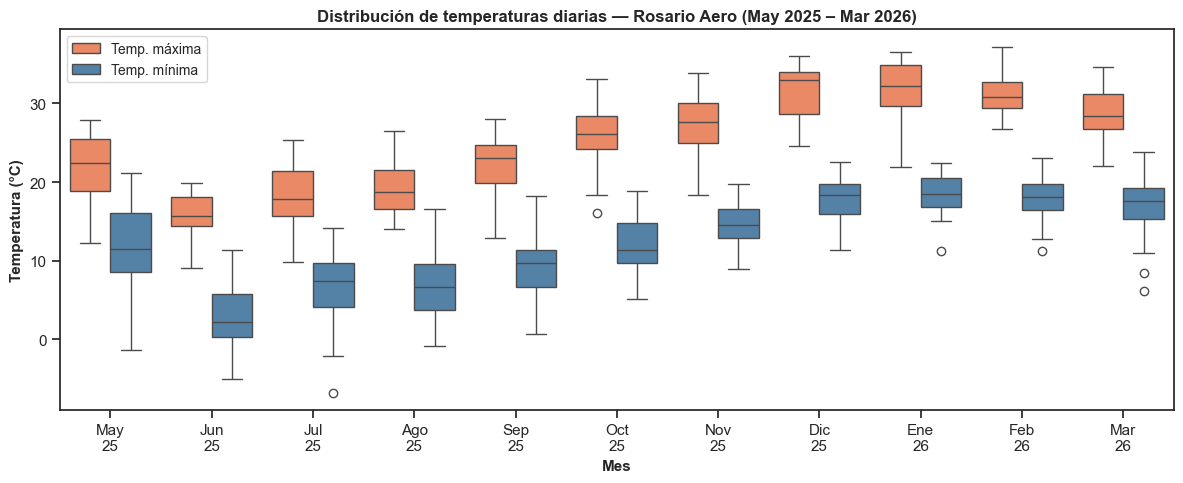

In [4]:
df_rosario = df_temp[df_temp['NOMBRE'] == 'ROSARIO AERO'].copy()

df_rosario_10m = df_rosario[
    ((df_rosario['AÑO'] == 2025) & (df_rosario['MES'] >= 5)) |
    ((df_rosario['AÑO'] == 2026) & (df_rosario['MES'] <= 3))
].copy()

df_rosario_10m['PERIODO'] = df_rosario_10m['FECHA'].dt.to_period('M').astype(str)
orden = sorted(df_rosario_10m['PERIODO'].unique())

meses_es = {'01': 'Ene', '02': 'Feb', '03': 'Mar', '04': 'Abr', '05': 'May',
            '06': 'Jun', '07': 'Jul', '08': 'Ago', '09': 'Sep', '10': 'Oct',
            '11': 'Nov', '12': 'Dic'}
etiquetas = [meses_es[p[5:7]] + '\n' + p[2:4] for p in orden]

df_melt = df_rosario_10m.melt(
    id_vars=['FECHA', 'MES', 'AÑO', 'PERIODO'],
    value_vars=['TMAX', 'TMIN'],
    var_name='Tipo',
    value_name='Temperatura'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='PERIODO', y='Temperatura', hue='Tipo', data=df_melt,
            order=orden, palette={'TMAX': 'coral', 'TMIN': 'steelblue'}, ax=ax)
ax.set_xticklabels(etiquetas)
ax.set_xlabel('Mes', fontweight='bold', fontsize=11)
ax.set_ylabel('Temperatura (°C)', fontweight='bold', fontsize=11)
ax.set_title('Distribución de temperaturas diarias — Rosario Aero (May 2025 – Mar 2026)',
             fontweight='bold')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Temp. máxima', 'Temp. mínima'], title='', fontsize=10)
plt.tight_layout()
plt.show()

## Ítem 4 — Respuestas a partir de la tabla y el gráfico

> **En base a lo realizado en los ítems anteriores, responda las siguientes preguntas:**
>
> **a.** ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?
>
> **b.** ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?
>
> **c.** Considerando la variabilidad del 50% central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas?
>
> **d.** ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?
>
> **e.** Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?

In [5]:
resumen_ros = df_rosario_10m.groupby('PERIODO')[['TMAX', 'TMIN']].agg(
    ['median', lambda x: x.quantile(0.75) - x.quantile(0.25), lambda x: x.max() - x.min()]
)
resumen_ros.columns = pd.MultiIndex.from_product(
    [['TMAX', 'TMIN'], ['Mediana', 'IQR', 'Rango']]
)
resumen_ros.index = [meses_es[p[5:7]] + ' ' + p[:4] for p in resumen_ros.index]

print('Tabla de resumen por mes (Rosario Aero):')
display(resumen_ros.round(2))

Tabla de resumen por mes (Rosario Aero):


TMAX                TMIN            
         Mediana   IQR Rango Mediana   IQR Rango
May 2025   22.40  6.60  15.6   11.50  7.50  22.6
Jun 2025   15.65  3.70  10.8    2.25  5.45  16.3
Jul 2025   17.80  5.70  15.6    7.40  5.60  20.9
Ago 2025   18.70  4.90  12.5    6.70  5.80  17.4
Sep 2025   23.10  4.75  15.1    9.65  4.70  17.5
Oct 2025   26.10  4.25  17.0   11.40  5.05  13.8
Nov 2025   27.65  5.10  15.5   14.55  3.80  10.9
Dic 2025   33.00  5.35  11.4   18.30  3.80  11.2
Ene 2026   32.20  5.20  14.6   18.50  3.65  11.2
Feb 2026   30.80  3.40  10.4   18.05  3.35  11.8
Mar 2026   28.40  4.50  12.6   17.60  4.05  17.6

In [6]:
# a) Mes con mayor TMAX mediana
mes_max_tmax = resumen_ros['TMAX']['Mediana'].idxmax()
print(f'a) Mes con mayor temperatura máxima mediana: {mes_max_tmax} ({resumen_ros.loc[mes_max_tmax, ("TMAX", "Mediana")]} °C)')

# b) Mes con menor TMIN mediana
mes_min_tmin = resumen_ros['TMIN']['Mediana'].idxmin()
print(f'b) Mes con menor temperatura mínima mediana: {mes_min_tmin} ({resumen_ros.loc[mes_min_tmin, ("TMIN", "Mediana")]} °C)')

# c) Mes con menor IQR en ambas temperaturas
df_rosario_10m['IQR_TMAX'] = df_rosario_10m.groupby('PERIODO')['TMAX'].transform(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)
df_rosario_10m['IQR_TMIN'] = df_rosario_10m.groupby('PERIODO')['TMIN'].transform(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)
print(f'c) IQR TMAX por mes:')
print(resumen_ros['TMAX']['IQR'].sort_values())
print(f'\n   IQR TMIN por mes:')
print(resumen_ros['TMIN']['IQR'].sort_values())

# d) Mes con mayor amplitud en TMIN
mes_mayor_rango_tmin = resumen_ros['TMIN']['Rango'].idxmax()
print(f'\nd) Mes con mayor amplitud en temperatura mínima: {mes_mayor_rango_tmin} ({resumen_ros.loc[mes_mayor_rango_tmin, ("TMIN", "Rango")]:.1f} °C de rango)')

a) Mes con mayor temperatura máxima mediana: Dic 2025 (33.0 °C)
b) Mes con menor temperatura mínima mediana: Jun 2025 (2.25 °C)
c) IQR TMAX por mes:
Feb 2026    3.40
Jun 2025    3.70
Oct 2025    4.25
Mar 2026    4.50
Sep 2025    4.75
Ago 2025    4.90
Nov 2025    5.10
Ene 2026    5.20
Dic 2025    5.35
Jul 2025    5.70
May 2025    6.60
Name: IQR, dtype: float64

   IQR TMIN por mes:
Feb 2026    3.35
Ene 2026    3.65
Nov 2025    3.80
Dic 2025    3.80
Mar 2026    4.05
Sep 2025    4.70
Oct 2025    5.05
Jun 2025    5.45
Jul 2025    5.60
Ago 2025    5.80
May 2025    7.50
Name: IQR, dtype: float64

d) Mes con mayor amplitud en temperatura mínima: May 2025 (22.6 °C de rango)


C:\Users\PC\AppData\Local\Temp\ipykernel_2092\2725421370.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PERIODO', y='TMAX', data=df_invierno, order=ordn_inv, palette='Blues_d')
C:\Users\PC\AppData\Local\Temp\ipykernel_2092\2725421370.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(etlq_inv)


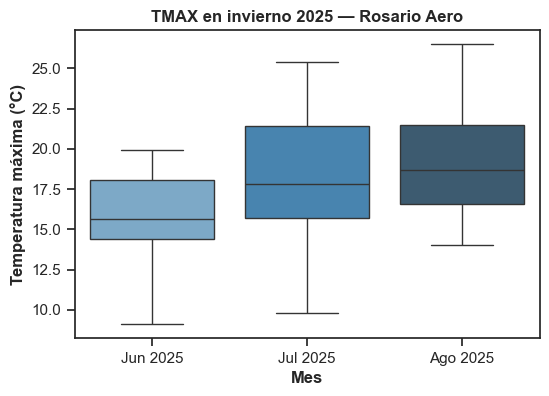

In [7]:
# e) Invierno 2025 (Jun, Jul, Ago) — ¿hubo TMAX atípica?
df_invierno = df_rosario_10m[df_rosario_10m['MES'].isin([6, 7, 8])].copy()
df_invierno['PERIODO'] = df_invierno['FECHA'].dt.to_period('M').astype(str)

ordn_inv = sorted(df_invierno['PERIODO'].unique())
etlq_inv = [meses_es[p[5:7]] + ' ' + p[:4] for p in ordn_inv]

plt.figure(figsize=(6, 4))
sns.boxplot(x='PERIODO', y='TMAX', data=df_invierno, order=ordn_inv, palette='Blues_d')
plt.gca().set_xticklabels(etlq_inv)
plt.xlabel('Mes', fontweight='bold')
plt.ylabel('Temperatura máxima (°C)', fontweight='bold')
plt.title('TMAX en invierno 2025 — Rosario Aero', fontweight='bold')
plt.show()

## Ítem 5 — Distribuciones en Base Marambio y comparación

> **Realice nuevamente el ítem 3 con los datos correspondientes a la estación meteorológica localizada en la Base Marambio de la Antártida Argentina. Compare los dos gráficos y comente las diferencias que encuentra en las distribuciones de las temperaturas registradas en ambas estaciones.**

C:\Users\PC\AppData\Local\Temp\ipykernel_2092\899366741.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(etiquetas)
C:\Users\PC\AppData\Local\Temp\ipykernel_2092\899366741.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(etiquetasM)


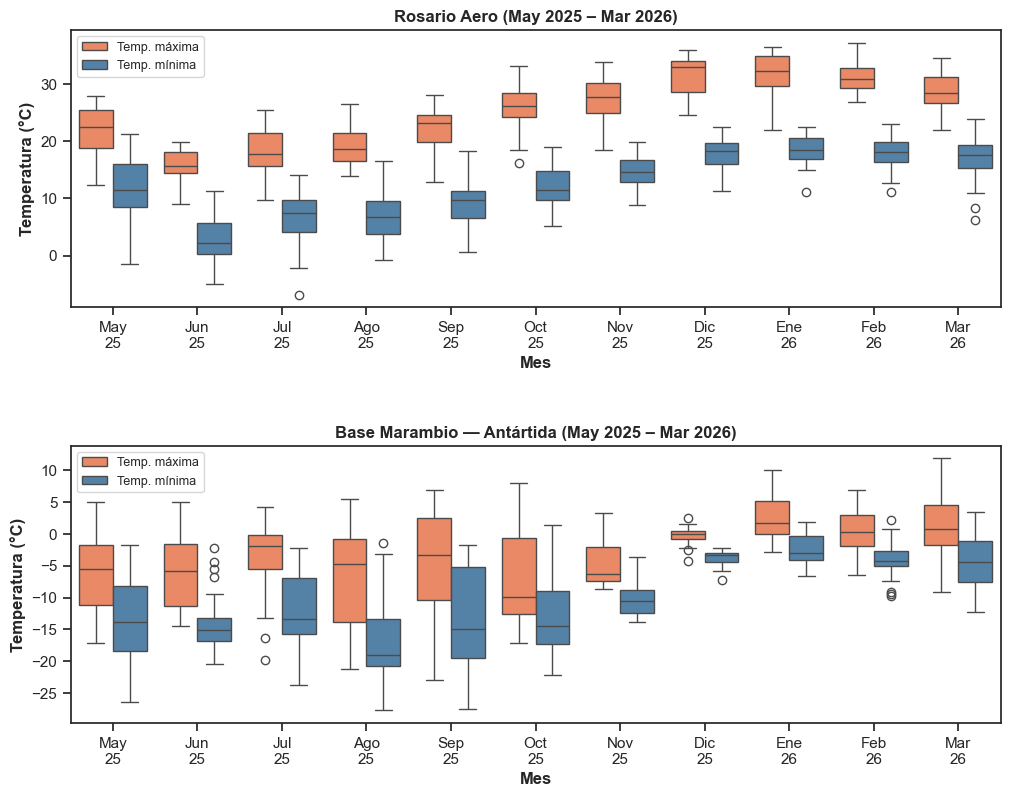

In [8]:
df_marambio = df_temp[df_temp['NOMBRE'].str.contains('MARAMBIO', na=False)].copy()

df_marambio_10m = df_marambio[
    ((df_marambio['AÑO'] == 2025) & (df_marambio['MES'] >= 5)) |
    ((df_marambio['AÑO'] == 2026) & (df_marambio['MES'] <= 3))
].copy()

df_marambio_10m['PERIODO'] = df_marambio_10m['FECHA'].dt.to_period('M').astype(str)
ordenM = sorted(df_marambio_10m['PERIODO'].unique())
etiquetasM = [meses_es[p[5:7]] + '\n' + p[2:4] for p in ordenM]

df_meltM = df_marambio_10m.melt(
    id_vars=['FECHA', 'MES', 'AÑO', 'PERIODO'],
    value_vars=['TMAX', 'TMIN'],
    var_name='Tipo',
    value_name='Temperatura'
)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plt.subplots_adjust(hspace=0.5)

sns.boxplot(x='PERIODO', y='Temperatura', hue='Tipo', data=df_melt,
            order=orden, palette={'TMAX': 'coral', 'TMIN': 'steelblue'}, ax=axes[0])
axes[0].set_xticklabels(etiquetas)
axes[0].set_title('Rosario Aero (May 2025 – Mar 2026)', fontweight='bold')
axes[0].set_xlabel('Mes', fontweight='bold')
axes[0].set_ylabel('Temperatura (°C)', fontweight='bold')
handles0, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles0, ['Temp. máxima', 'Temp. mínima'], title='', fontsize=9)

sns.boxplot(x='PERIODO', y='Temperatura', hue='Tipo', data=df_meltM,
            order=ordenM, palette={'TMAX': 'coral', 'TMIN': 'steelblue'}, ax=axes[1])
axes[1].set_xticklabels(etiquetasM)
axes[1].set_title('Base Marambio — Antártida (May 2025 – Mar 2026)', fontweight='bold')
axes[1].set_xlabel('Mes', fontweight='bold')
axes[1].set_ylabel('Temperatura (°C)', fontweight='bold')
handles1, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles1, ['Temp. máxima', 'Temp. mínima'], title='', fontsize=9)

plt.show()

**Comparación:**
- Las temperaturas en Rosario son consistentemente más altas y muestran la estacionalidad típica del hemisferio sur: máximos en verano (diciembre–febrero) y mínimos en invierno (junio–agosto).
- En Base Marambio las temperaturas son mucho más bajas en todo el año y la amplitud entre máximas y mínimas es menor. El invierno austral (jun–ago) es extremadamente frío con medianas por debajo de los -10 °C.